# Lesson 16 activity: feature engineering

## Notebook set up

Submit your notebook to the class leaderboard on HuggingFace at [huggingface.co/spaces/gperdrizet/leaderboard](https://huggingface.co/spaces/gperdrizet/leaderboard)

**Your task**: Apply at least two different feature engineering techniques to the `housing_df` dataframe to improve the dataset. At the end of the notebook, your engineered dataset and the original dataset will be used to train a linear regression model to predict `MedHouseVal`. Your goal is to achieve better model performance via feature engineering.

Don't change any of the code in the Model evaluation section of the notebook, especially the output saving. Otherwise the leaderboard scoring may not work!

Before applying transformations, explore the dataset to understand what techniques might be most beneficial.

### Import libraries

In [1]:
!pip install seaborn

In [2]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

# Set random seed for reproducibility
np.random.seed(315)

### Load dataset

In [3]:
# Load California housing dataset
original_housing_df = pd.read_csv('https://media.githubusercontent.com/media/gperdrizet/fullstack-2605/refs/heads/main/data/california_housing.csv')
housing_df = original_housing_df.copy()

## Task 1: Explore the dataset

Before deciding what feature engineering techniques to apply, explore the dataset to understand its characteristics.

**Things to investigate**:
- Display basic information about the dataset (`.info()`, `.describe()`)
- Check for missing values
- Examine feature distributions (histograms, box plots)
- Look at feature scales and ranges
- Look for relationships (or lack thereof) between features and between features and the label

Use this exploration to inform your feature engineering decisions in the following tasks.

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
Missing Values:
 MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


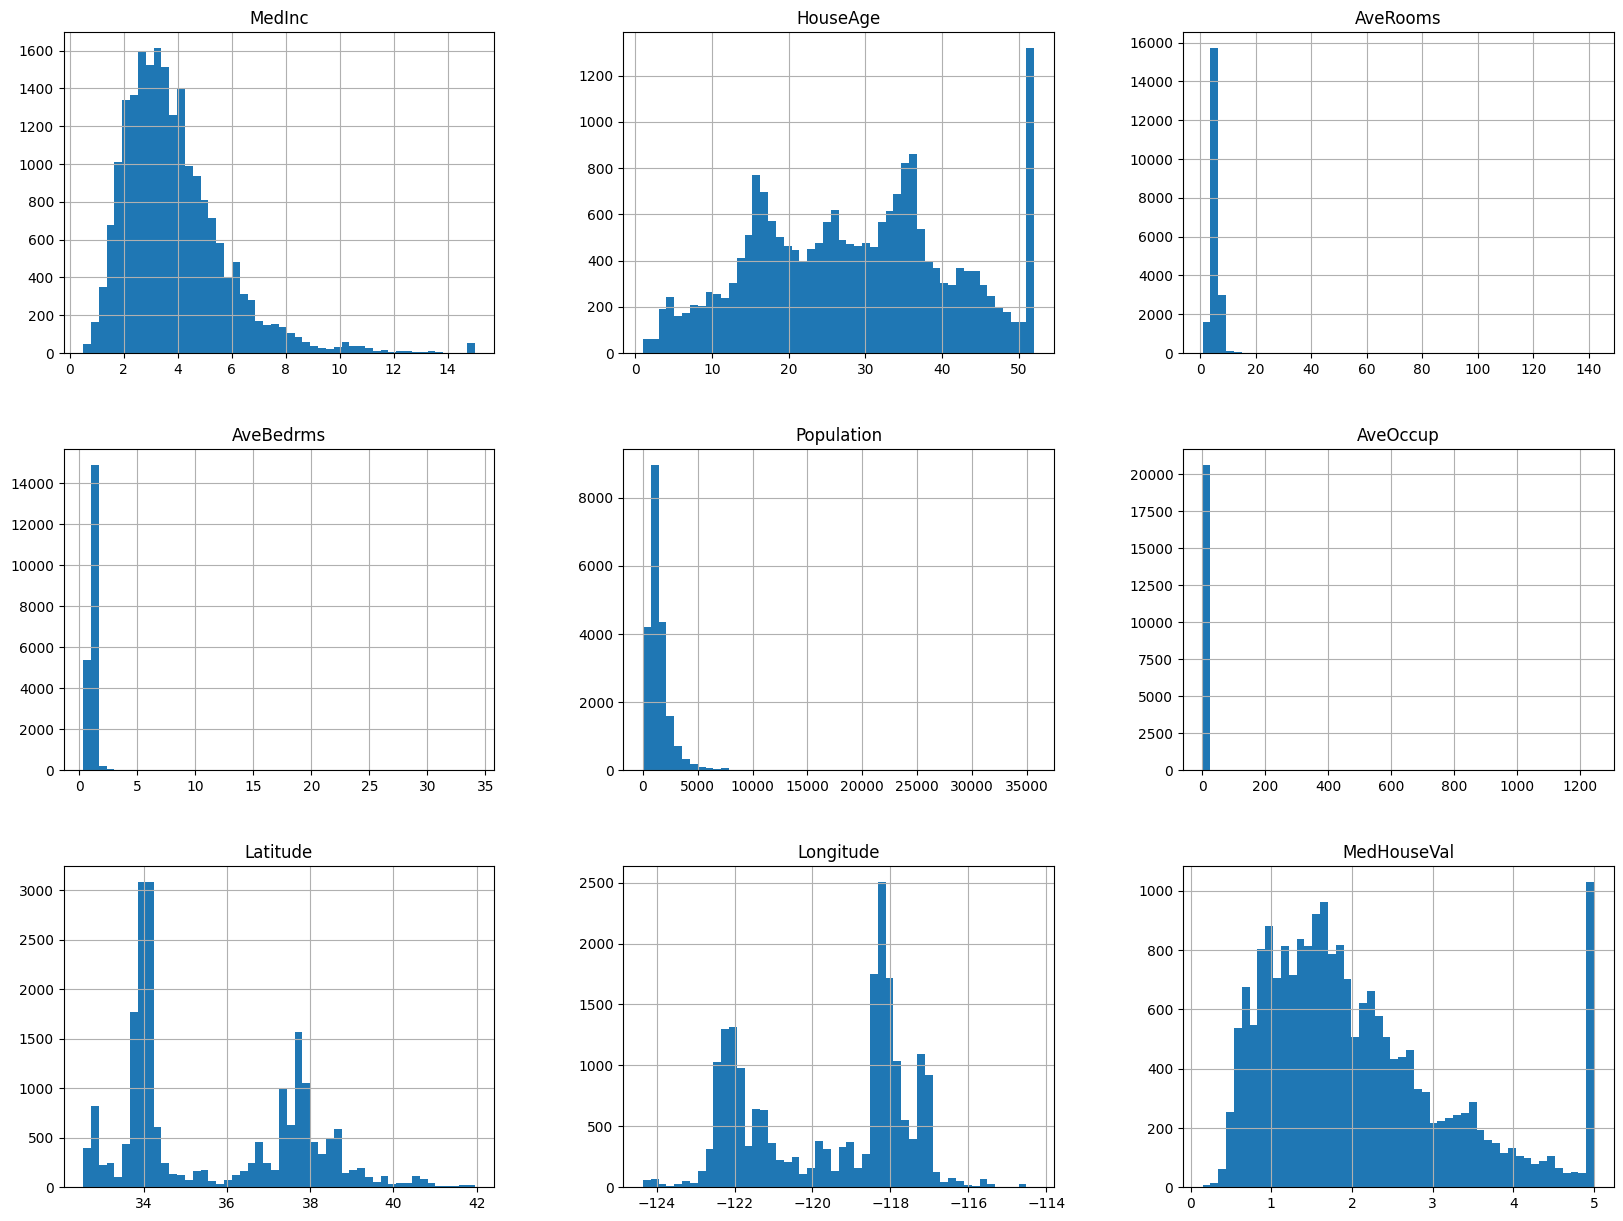

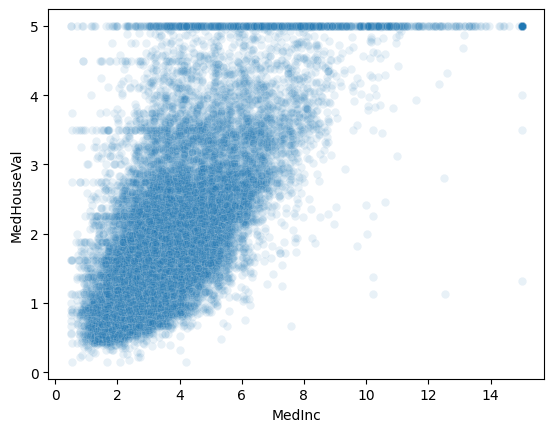

In [4]:
# YOUR CODE HERE
housing_df.info()
housing_df.describe()

import seaborn as sns
# Check for missing values
print("Missing Values:\n", housing_df.isnull().sum())
# Note: no missing values or they'll be handled.

# distributions
housing_df.hist(bins=50, figsize=(20,15))
plt.show()

# log MedInc? It has a tail
# The target MedHouseVal is capped at 5.

# Also look at MedInc vs MedHouseVal
sns.scatterplot(x='MedInc', y='MedHouseVal', data=housing_df, alpha=0.1)
plt.show()

## Task 2: Apply your first feature engineering technique

Based on your exploration, apply your first feature engineering technique.

**Example approaches**:
- Transform skewed features using log, sqrt, power, or quantile transformations
- Create bins/categories from continuous variables
- Create interaction features (e.g., rooms per household = total rooms / households)

In [5]:
# YOUR CODE HERE
# Feature engineering 1: Add interaction terms, useful ratios for this dataset
# Rooms per household
housing_df['Rooms_per_Household'] = housing_df['AveRooms']

# Wait, `AveRooms` actually might already be average rooms per household. Let's check columns:
# It usually has MedInc, HouseAge, AveRooms, AveBedrms, Population, AveOccup, Latitude, Longitude
# Let's create 'Bedrooms_per_Room' as a ratio.
housing_df['Bedrooms_per_Room'] = housing_df['AveBedrms'] / housing_df['AveRooms']

# Let's log-transform some skewed features like AveRooms, AveBedrms, Population, AveOccup which have massive outliers.
features_to_log = ['AveRooms', 'AveBedrms', 'Population', 'AveOccup']
for feature in features_to_log:
    # Adding a small constant if there are zeros
    housing_df[f'{feature}_log'] = np.log1p(housing_df[feature])

# Drop original skewed ones if you want, or leave them. Let's leave them for linear regression to figure out, or actually replace them.
housing_df = housing_df.drop(columns=features_to_log)


## Task 3: Apply your second feature engineering technique

**Example approaches**:
- Scale features to similar ranges
- Encode any categorical variables you created
- Create aggregate statistics by groups

In [6]:
# YOUR CODE HERE
# Feature engineering 2: Scaling / Geographical clustering
from sklearn.preprocessing import StandardScaler

# Handle capping in MedHouseVal and HouseAge? The instructions don't strictly require dropping it,
# but Linear Regression might benefit from standard scaling all features.
scaler = StandardScaler()
# excluding MedHouseVal
features_to_scale = housing_df.columns.drop('MedHouseVal')
housing_df[features_to_scale] = scaler.fit_transform(housing_df[features_to_scale])

# Also let's try bucketing latitude / longitude or using a combination (distance form SF / LA)
# But Standard Scaler alone is a good second technique for linear regression, which is scale variant if penalized (not penalized here but still good practice).


## (Optional) Additional feature engineering

Add more techniques if you'd like to experiment further.

In [7]:
# YOUR CODE HERE (optional)


## Model evaluation

Now we'll compare model performance on the original dataset versus your engineered dataset.

### Evaluate datasets

In [8]:
# Create output directory if it doesn't exist
output_directory = 'data/outputs'
Path(output_directory).mkdir(parents=True, exist_ok=True)

# Save a copy of the engineered dataframe
housing_df.to_csv('data/outputs/housing_df.csv', index=False)

In [9]:
# Create linear regression model
model = LinearRegression()

# Evaluate on original dataset
scores_original = cross_val_score(
    model,
    original_housing_df.drop('MedHouseVal', axis=1),
    original_housing_df['MedHouseVal'],
    cv=10,
    scoring='r2'
)

# Evaluate on engineered dataset
scores_engineered = cross_val_score(
    model,
    housing_df.drop('MedHouseVal', axis=1),
    housing_df['MedHouseVal'],
    cv=10,
    scoring='r2'
)

engineered_mean = scores_engineered.mean()
original_mean = scores_original.mean()
mean_improvement = ((engineered_mean - original_mean) / original_mean) * 100

print(f'\nMean improvement: {mean_improvement:.2f}%')


Mean improvement: 11.62%


### Visualize model performance comparison

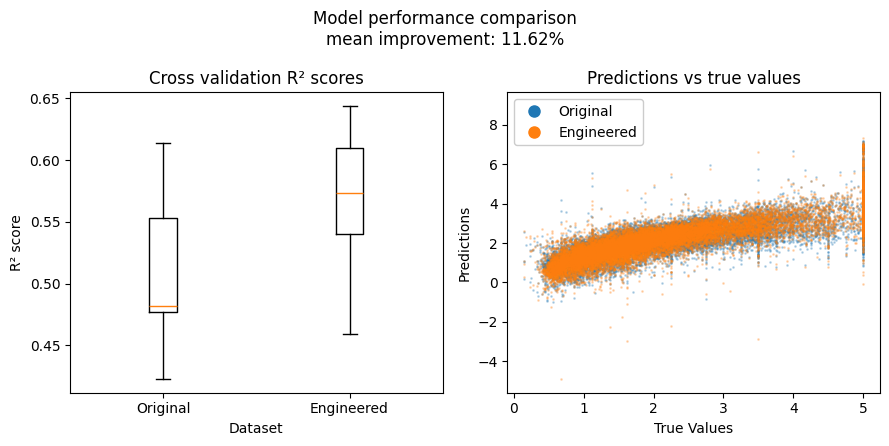

In [10]:
original_model = LinearRegression()
original_model.fit(original_housing_df.drop('MedHouseVal', axis=1), original_housing_df['MedHouseVal'])
original_predictions = original_model.predict(original_housing_df.drop('MedHouseVal', axis=1))

model = LinearRegression()
model.fit(housing_df.drop('MedHouseVal', axis=1), housing_df['MedHouseVal'])
predictions = model.predict(housing_df.drop('MedHouseVal', axis=1))

# Create boxplot comparing performance
data_to_plot = [scores_original, scores_engineered]
labels = ['Original', 'Engineered']

fig, axs = plt.subplots(1, 2, figsize=(9,4.5))

fig.suptitle(f'Model performance comparison\nmean improvement: {mean_improvement:.2f}%')

axs[0].set_title('Cross validation R² scores')
axs[0].boxplot(data_to_plot, tick_labels=labels)
axs[0].set_xlabel('Dataset')
axs[0].set_ylabel('R² score')

axs[1].set_title('Predictions vs true values')
axs[1].plot(
    original_housing_df['MedHouseVal'], original_predictions,
    'o', markersize=1, label='Original', alpha=0.25
)

axs[1].plot(
    housing_df['MedHouseVal'], predictions,
    'o', markersize=1, label='Engineered', alpha=0.25
)

axs[1].set_xlabel('True Values')
axs[1].set_ylabel('Predictions')

leg = axs[1].legend(loc='upper left', markerscale=8, framealpha=1)

for lh in leg.legend_handles:
    lh.set_alpha(1)

plt.tight_layout()
plt.show()

## 3. Reflection

**Questions to consider**:

1. Which feature engineering techniques had the biggest impact on model performance?
2. Did adding more features always improve performance, or did some hurt it?
3. How might you further improve the engineered dataset?
4. What trade-offs did you consider (e.g., interpretability vs performance, complexity vs gains)?